# 03 - Compare Results

This notebook compares the Classical Models and IndoBERT experiments.

The comparison includes:
- loading classical model results from notebook 01,
- loading IndoBERT metrics and checkpoint-based reports from notebook 02,
- building a combined comparison table,
- plotting metric comparison charts,
- plotting available confusion matrices,
- saving the combined summary files to `outputs_indobert/final_results`.

**Run the notebook sequentially from top to bottom.** This notebook only performs evaluation and comparison; it does not retrain any model.


## 1. Imports

In [1]:
import json
import re
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

warnings.filterwarnings("ignore")
print("Imports OK")

Imports OK


## 2. Paths and Fallback Data

In [2]:
# ============================================================
# 1. Paths
# ============================================================

# Mount Google Drive only when running in Colab.
try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception as e:
    print("Drive mount skipped:", e)

PROJECT_DIR = Path("/content/drive/MyDrive/NLPAOL_V3")

# Classical results from notebook 01
CLASSICAL_JSON = PROJECT_DIR / "outputs" / "classical_models_all_agree" / "classical_results.json"

# IndoBERT outputs from notebook 02
INDOBERT_DIR = PROJECT_DIR / "outputs_indobert" / "final_results"
INDOBERT_CSV = INDOBERT_DIR / "indobert_all_experiments.csv"
INDOBERT_MODEL_DIR = PROJECT_DIR / "outputs_indobert" / "indobert_model"

OUTPUT_DIR = INDOBERT_DIR
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

REPORT_PATHS = {
    "indobert_imbalance":         INDOBERT_DIR / "indobert_imbalance_report.txt",
    "indobert_balance":           INDOBERT_DIR / "indobert_balance_report.txt",
    "indobert_imbalance_augment": INDOBERT_DIR / "indobert_imbalance_augment_report.txt",
    "indobert_balance_augment":   INDOBERT_DIR / "indobert_balance_augment_report.txt",
}

SETTING_LABELS = {
    "indobert_imbalance":         "Imbalance",
    "indobert_balance":           "Balance",
    "indobert_imbalance_augment": "Imbalance+Aug",
    "indobert_balance_augment":   "Balance+Aug",
}

# Fallback confusion matrices from your checkpoint evaluation output.
# Format: [[TN, FP], [FN, TP]]
INDOBERT_CM_FALLBACK = {
    "indobert_imbalance":         [[507, 23], [32, 300]],
    "indobert_balance":           [[512, 18], [32, 300]],
    "indobert_imbalance_augment": [[503, 27], [27, 305]],
    "indobert_balance_augment":   [[513, 17], [29, 303]],
}

# Fallback metrics from your checkpoint evaluation output.
INDOBERT_METRIC_FALLBACK = {
    "indobert_imbalance": {
        "accuracy": 0.9362, "precision_macro": 0.9347, "recall_macro": 0.9301,
        "f1_macro": 0.9323, "f1_weighted": 0.9360,
    },
    "indobert_balance": {
        "accuracy": 0.9420, "precision_macro": 0.9423, "recall_macro": 0.9348,
        "f1_macro": 0.9383, "f1_weighted": 0.9417,
    },
    "indobert_imbalance_augment": {
        "accuracy": 0.9374, "precision_macro": 0.9339, "recall_macro": 0.9339,
        "f1_macro": 0.9339, "f1_weighted": 0.9374,
    },
    "indobert_balance_augment": {
        "accuracy": 0.9466, "precision_macro": 0.9467, "recall_macro": 0.9403,
        "f1_macro": 0.9433, "f1_weighted": 0.9464,
    },
}

print("PROJECT_DIR  :", PROJECT_DIR, "| exists:", PROJECT_DIR.exists())
print("CLASSICAL_JSON:", CLASSICAL_JSON, "| exists:", CLASSICAL_JSON.exists())
print("INDOBERT_DIR :", INDOBERT_DIR, "| exists:", INDOBERT_DIR.exists())
print("INDOBERT_CSV :", INDOBERT_CSV, "| exists:", INDOBERT_CSV.exists())
print()

print("IndoBERT report files:")
for name, path in REPORT_PATHS.items():
    print(f"  {name:<35} | {'FOUND' if path.exists() else 'not found'}")

Mounted at /content/drive
PROJECT_DIR  : /content/drive/MyDrive/NLPAOL_V3 | exists: True
CLASSICAL_JSON: /content/drive/MyDrive/NLPAOL_V3/outputs/classical_models_all_agree/classical_results.json | exists: True
INDOBERT_DIR : /content/drive/MyDrive/NLPAOL_V3/outputs_indobert/final_results | exists: True
INDOBERT_CSV : /content/drive/MyDrive/NLPAOL_V3/outputs_indobert/final_results/indobert_all_experiments.csv | exists: True

IndoBERT report files:
  indobert_imbalance                  | FOUND
  indobert_balance                    | FOUND
  indobert_imbalance_augment          | FOUND
  indobert_balance_augment            | FOUND


## 3. Helper Functions

In [3]:
# ============================================================
# 2. Helper Functions
# ============================================================

def safe_float(value):
    """Convert value to float; return None if invalid/NaN."""
    try:
        if value is None:
            return None
        value = float(value)
        if math.isnan(value):
            return None
        return value
    except Exception:
        return None


def short_model_name(name):
    """Shorten long model names for plots."""
    return (
        str(name)
        .replace("Multinomial Naive Bayes", "MNB")
        .replace("Logistic Regression", "LR")
        .replace("SVM (LinearSVC + Calibrated)", "SVM")
        .replace("indobert_", "IndoBERT ")
    )


def parse_cm_from_text(text):
    """
    Parse confusion matrix from report text if present.
    Supported formats:
    1) Actual Non-CB TN FP / Actual CB FN TP
    2) Confusion Matrix: [[TN FP] [FN TP]]
    Returns [[TN, FP], [FN, TP]] or None.
    """
    if not text:
        return None

    # Format written by the checkpoint evaluation report.
    m = re.search(
        r"Actual\s+Non[- ]CB\s+(\d+)\s+(\d+)\s*[\r\n]+Actual\s+CB\s+(\d+)\s+(\d+)",
        text,
        flags=re.IGNORECASE,
    )
    if m:
        tn, fp, fn, tp = map(int, m.groups())
        return [[tn, fp], [fn, tp]]

    # More flexible single-line matching
    m = re.search(
        r"Actual\s+Non[- ]CB\s+(\d+)\s+(\d+).*?Actual\s+CB\s+(\d+)\s+(\d+)",
        text,
        flags=re.IGNORECASE | re.DOTALL,
    )
    if m:
        tn, fp, fn, tp = map(int, m.groups())
        return [[tn, fp], [fn, tp]]

    # Numpy-like matrix printed as:
    # [[507  23]
    #  [ 32 300]]
    matrix_match = re.search(
        r"\[\[\s*(\d+)\s+(\d+)\s*\]\s*\[\s*(\d+)\s+(\d+)\s*\]\]",
        text.replace("\n", " "),
    )
    if matrix_match:
        tn, fp, fn, tp = map(int, matrix_match.groups())
        return [[tn, fp], [fn, tp]]

    return None


def parse_report_txt(path):
    """
    Parse metrics from IndoBERT report .txt.
    If some values are missing, they will be filled later from fallback.
    """
    path = Path(path)
    if not path.exists():
        return {}

    text = path.read_text(encoding="utf-8")
    result = {}

    # Accuracy can appear as "accuracy 0.9362 862" or "Accuracy : 0.9362"
    m = re.search(r"\baccuracy\b\s+([0-9.]+)", text, flags=re.IGNORECASE)
    if not m:
        m = re.search(r"Accuracy\s*:\s*([0-9.]+)", text, flags=re.IGNORECASE)
    result["accuracy"] = safe_float(m.group(1)) if m else None

    # Macro avg row from sklearn classification_report:
    # macro avg  precision recall f1-score support
    m = re.search(r"macro\s+avg\s+([0-9.]+)\s+([0-9.]+)\s+([0-9.]+)", text, flags=re.IGNORECASE)
    if m:
        result["precision_macro"] = safe_float(m.group(1))
        result["recall_macro"] = safe_float(m.group(2))
        result["f1_macro"] = safe_float(m.group(3))
    else:
        result["precision_macro"] = None
        result["recall_macro"] = None
        result["f1_macro"] = None

    # Weighted avg row
    m = re.search(r"weighted\s+avg\s+([0-9.]+)\s+([0-9.]+)\s+([0-9.]+)", text, flags=re.IGNORECASE)
    result["f1_weighted"] = safe_float(m.group(3)) if m else None

    result["confusion_matrix"] = parse_cm_from_text(text)
    return result


def fill_missing(base, extra):
    """Fill missing None values in base dict using extra dict."""
    for key, value in extra.items():
        if base.get(key) is None and value is not None:
            base[key] = value
    return base


def validate_cm(cm):
    """Return a valid 2x2 confusion matrix list or None."""
    if cm is None:
        return None
    arr = np.array(cm)
    if arr.shape != (2, 2):
        return None
    return arr.astype(int).tolist()


print("Helper functions OK")

Helper functions OK


## 4. Load Classical Results

In [4]:
# ============================================================
# 3. Load Classical Results
# ============================================================

classical = []

if CLASSICAL_JSON.exists():
    with open(CLASSICAL_JSON, "r", encoding="utf-8") as f:
        classical = json.load(f)

    print(f"Loaded {len(classical)} classical models")
    print()
    print(f"{'Model':<35} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7} {'AUC':>7}")
    print("-" * 72)

    for r in classical:
        model_name = r.get("model", "Unknown")
        acc = safe_float(r.get("accuracy"))
        prec = safe_float(r.get("precision_macro"))
        rec = safe_float(r.get("recall_macro"))
        f1 = safe_float(r.get("f1_macro"))
        auc = safe_float(r.get("auc_roc"))

        print(
            f"  {model_name:<33} "
            f"{acc if acc is not None else 0:>7.4f} "
            f"{prec if prec is not None else 0:>7.4f} "
            f"{rec if rec is not None else 0:>7.4f} "
            f"{f1 if f1 is not None else 0:>7.4f} "
            f"{auc if auc is not None else 0:>7.4f}"
        )
else:
    print("Classical JSON not found. Classical models will be skipped.")

Loaded 3 classical models

Model                                   Acc    Prec     Rec      F1     AUC
------------------------------------------------------------------------
  Multinomial Naive Bayes            0.8721  0.8808  0.8485  0.8597  0.9401
  Logistic Regression                0.9081  0.9109  0.8942  0.9011  0.9614
  SVM (LinearSVC + Calibrated)       0.9116  0.9165  0.8965  0.9046  0.9611


## 5. Load IndoBERT Results

In [5]:
# ============================================================
# 4. Load IndoBERT Results
# ============================================================

indobert_results = {}

# 4.1 Start with CSV if available
if INDOBERT_CSV.exists():
    csv_df = pd.read_csv(INDOBERT_CSV)
    print(f"Loaded IndoBERT CSV: {len(csv_df)} rows")

    for _, row in csv_df.iterrows():
        exp = row.get("experiment")
        if exp is None:
            continue

        exp = str(exp)
        indobert_results[exp] = {
            "experiment": exp,
            "setting_label": SETTING_LABELS.get(exp, exp),
            "accuracy": safe_float(row.get("test_accuracy")),
            "precision_macro": safe_float(row.get("test_precision")) or safe_float(row.get("precision_macro")),
            "recall_macro": safe_float(row.get("test_recall")) or safe_float(row.get("recall_macro")),
            "f1_macro": safe_float(row.get("test_f1_macro")) or safe_float(row.get("f1_macro")),
            "f1_weighted": safe_float(row.get("test_f1")) or safe_float(row.get("f1_weighted")),
            "val_f1": safe_float(row.get("val_f1")),
            "confusion_matrix": None,
            "source": "csv",
        }
else:
    print("IndoBERT CSV not found. Will use TXT/fallback data.")

# 4.2 Supplement from report txt
for exp, path in REPORT_PATHS.items():
    parsed = parse_report_txt(path)

    if exp not in indobert_results:
        indobert_results[exp] = {
            "experiment": exp,
            "setting_label": SETTING_LABELS.get(exp, exp),
            "accuracy": None,
            "precision_macro": None,
            "recall_macro": None,
            "f1_macro": None,
            "f1_weighted": None,
            "val_f1": None,
            "confusion_matrix": None,
            "source": "txt/fallback",
        }

    indobert_results[exp] = fill_missing(indobert_results[exp], parsed)

# 4.3 Guaranteed fallback from checkpoint output
for exp in SETTING_LABELS:
    if exp not in indobert_results:
        indobert_results[exp] = {
            "experiment": exp,
            "setting_label": SETTING_LABELS.get(exp, exp),
            "accuracy": None,
            "precision_macro": None,
            "recall_macro": None,
            "f1_macro": None,
            "f1_weighted": None,
            "val_f1": None,
            "confusion_matrix": None,
            "source": "fallback",
        }

    indobert_results[exp] = fill_missing(indobert_results[exp], INDOBERT_METRIC_FALLBACK.get(exp, {}))

    if validate_cm(indobert_results[exp].get("confusion_matrix")) is None:
        indobert_results[exp]["confusion_matrix"] = INDOBERT_CM_FALLBACK.get(exp)

print()
print("IndoBERT experiments loaded:")
for exp, r in indobert_results.items():
    cm_status = "CM OK" if validate_cm(r.get("confusion_matrix")) else "CM missing"
    print(
        f"  {exp:<35} "
        f"Acc={r.get('accuracy'):.4f} "
        f"Prec={r.get('precision_macro'):.4f} "
        f"Rec={r.get('recall_macro'):.4f} "
        f"F1={r.get('f1_macro'):.4f} "
        f"| {cm_status}"
    )

Loaded IndoBERT CSV: 4 rows

IndoBERT experiments loaded:
  indobert_imbalance                  Acc=0.9362 Prec=0.9347 Rec=0.9301 F1=0.9323 | CM OK
  indobert_balance                    Acc=0.9420 Prec=0.9423 Rec=0.9348 F1=0.9383 | CM OK
  indobert_imbalance_augment          Acc=0.9374 Prec=0.9339 Rec=0.9339 F1=0.9339 | CM OK
  indobert_balance_augment            Acc=0.9466 Prec=0.9467 Rec=0.9403 F1=0.9433 | CM OK


## 6. Comparison Table

In [6]:
# ============================================================
# 5. Build Comparison Table
# ============================================================

def fmt(val, d=4):
    val = safe_float(val)
    return f"{val:.{d}f}" if val is not None else "N/A"

def target_check(val, threshold):
    val = safe_float(val)
    if val is None:
        return "?"
    return "PASS" if val >= threshold else "FAIL"


rows = []

# Classical rows
for r in classical:
    rows.append({
        "Model": r.get("model", "Unknown Classical Model"),
        "Type": "Classical",
        "Experiment": r.get("model", "classical"),
        "Accuracy": safe_float(r.get("accuracy")),
        "Precision": safe_float(r.get("precision_macro")),
        "Recall": safe_float(r.get("recall_macro")),
        "F1": safe_float(r.get("f1_macro")),
        "AUC": safe_float(r.get("auc_roc")),
        "val_f1": None,
        "cm": validate_cm(r.get("confusion_matrix")),
    })

# IndoBERT rows
for exp, r in indobert_results.items():
    rows.append({
        "Model": f"IndoBERT ({r.get('setting_label', exp)})",
        "Type": "IndoBERT",
        "Experiment": exp,
        "Accuracy": safe_float(r.get("accuracy")),
        "Precision": safe_float(r.get("precision_macro")),
        "Recall": safe_float(r.get("recall_macro")),
        "F1": safe_float(r.get("f1_macro")),
        "AUC": None,
        "val_f1": safe_float(r.get("val_f1")),
        "cm": validate_cm(r.get("confusion_matrix")),
    })

# Sort by F1 descending
rows = sorted(rows, key=lambda x: x["F1"] if x["F1"] is not None else -1, reverse=True)

comparison_df = pd.DataFrame(rows)
display(comparison_df[["Model", "Type", "Accuracy", "Precision", "Recall", "F1", "AUC", "val_f1"]])

# Best IndoBERT selection:
# Prefer validation F1 if available. If not available, use test F1 only for reporting/ranking.
bert_rows = [r for r in rows if r["Type"] == "IndoBERT"]
bert_with_val = [r for r in bert_rows if r["val_f1"] is not None]

if bert_with_val:
    best_bert_row_for_history = max(bert_with_val, key=lambda x: x["val_f1"])
else:
    best_bert_row_for_history = max(bert_rows, key=lambda x: x["F1"] if x["F1"] is not None else -1)

BEST_INDOBERT_EXPERIMENT = best_bert_row_for_history["Experiment"]

print()
print("Best IndoBERT experiment for training curve:", BEST_INDOBERT_EXPERIMENT)
if best_bert_row_for_history["val_f1"] is not None:
    print("Selected by validation F1:", fmt(best_bert_row_for_history["val_f1"]))
else:
    print("Validation F1 not available; selected by test F1 for visualization only.")

print()
print("Note:")
print("- IndoBERT confusion matrices use checkpoint evaluation output; no retraining.")
print("- If classical and IndoBERT split were generated separately, comparison is valid overall but not identical sample-by-sample.")

,Model,Type,Accuracy,Precision,Recall,F1,AUC,val_f1
0,IndoBERT (Balance+Aug),IndoBERT,0.9466,0.9467,0.9403,0.9433,NaN,0.9501
1,IndoBERT (Balance),IndoBERT,0.9420,0.9423,0.9348,0.9383,NaN,0.9593
2,IndoBERT (Imbalance+Aug),IndoBERT,0.9374,0.9339,0.9339,0.9339,NaN,0.9583
3,IndoBERT (Imbalance),IndoBERT,0.9362,0.9347,0.9301,0.9323,NaN,0.9523
4,SVM (LinearSVC + Calibrated),Classical,0.9116,0.9165,0.8965,0.9046,0.9611,NaN
5,Logistic Regression,Classical,0.9081,0.9109,0.8942,0.9011,0.9614,NaN
6,Multinomial Naive Bayes,Classical,0.8721,0.8808,0.8485,0.8597,0.9401,NaN



Best IndoBERT experiment for training curve: indobert_balance
Selected by validation F1: 0.9593

Note:
- IndoBERT confusion matrices use checkpoint evaluation output; no retraining.
- If classical and IndoBERT split were generated separately, comparison is valid overall but not identical sample-by-sample.


## 7. Bar Chart

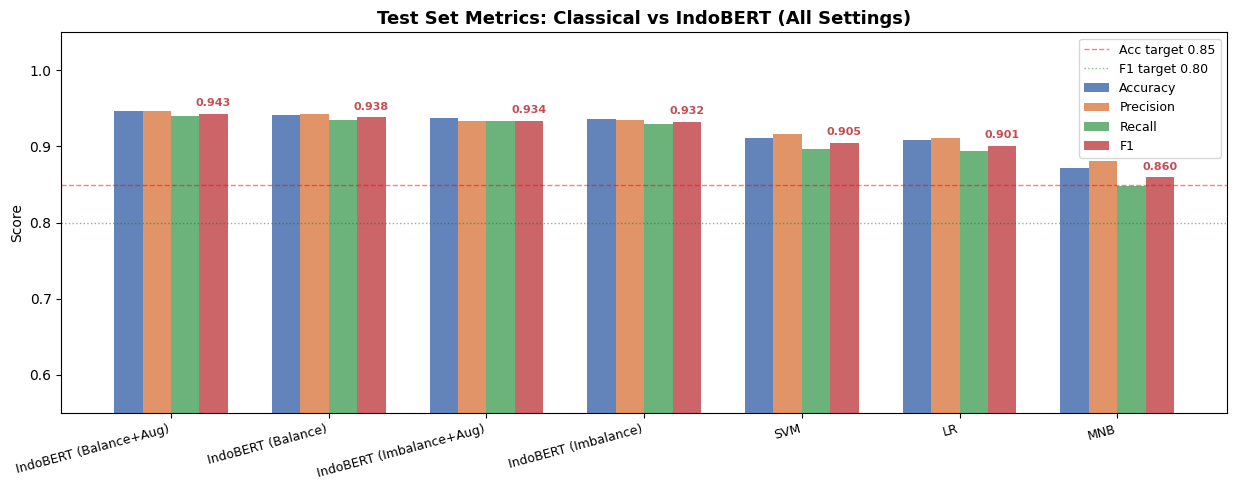

Saved: /content/drive/MyDrive/NLPAOL_V3/outputs_indobert/final_results/comparison_bar_chart.png


In [7]:
# ============================================================
# 6. Bar Chart: Metrics Comparison
# ============================================================

if not rows:
    print("No rows available to plot.")
else:
    short_names = [short_model_name(r["Model"]) for r in rows]
    x = np.arange(len(rows))
    w = 0.18

    metrics_plot = ["Accuracy", "Precision", "Recall", "F1"]
    metric_colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

    fig, ax = plt.subplots(figsize=(max(12, len(rows) * 1.8), 5))
    ax.set_title("Test Set Metrics: Classical vs IndoBERT (All Settings)", fontsize=13, fontweight="bold")

    for i, (metric, color) in enumerate(zip(metrics_plot, metric_colors)):
        vals = [r[metric] if r[metric] is not None else 0 for r in rows]
        ax.bar(x + i * w, vals, width=w, label=metric, color=color, alpha=0.87)

    ax.set_xticks(x + w * 1.5)
    ax.set_xticklabels(short_names, fontsize=9, rotation=15, ha="right")
    ax.set_ylim(0.55, 1.05)
    ax.set_ylabel("Score")
    ax.axhline(0.85, color="red", linestyle="--", linewidth=1, alpha=0.5, label="Acc target 0.85")
    ax.axhline(0.80, color="green", linestyle=":", linewidth=1, alpha=0.5, label="F1 target 0.80")
    ax.legend(fontsize=9)

    for i, r in enumerate(rows):
        if r["F1"] is not None:
            ax.text(
                i + 3 * w,
                r["F1"] + 0.010,
                f"{r['F1']:.3f}",
                ha="center",
                fontsize=8,
                color="#C44E52",
                fontweight="bold",
            )

    plt.tight_layout()
    out_path = OUTPUT_DIR / "comparison_bar_chart.png"
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path}")

## 8. Confusion Matrices

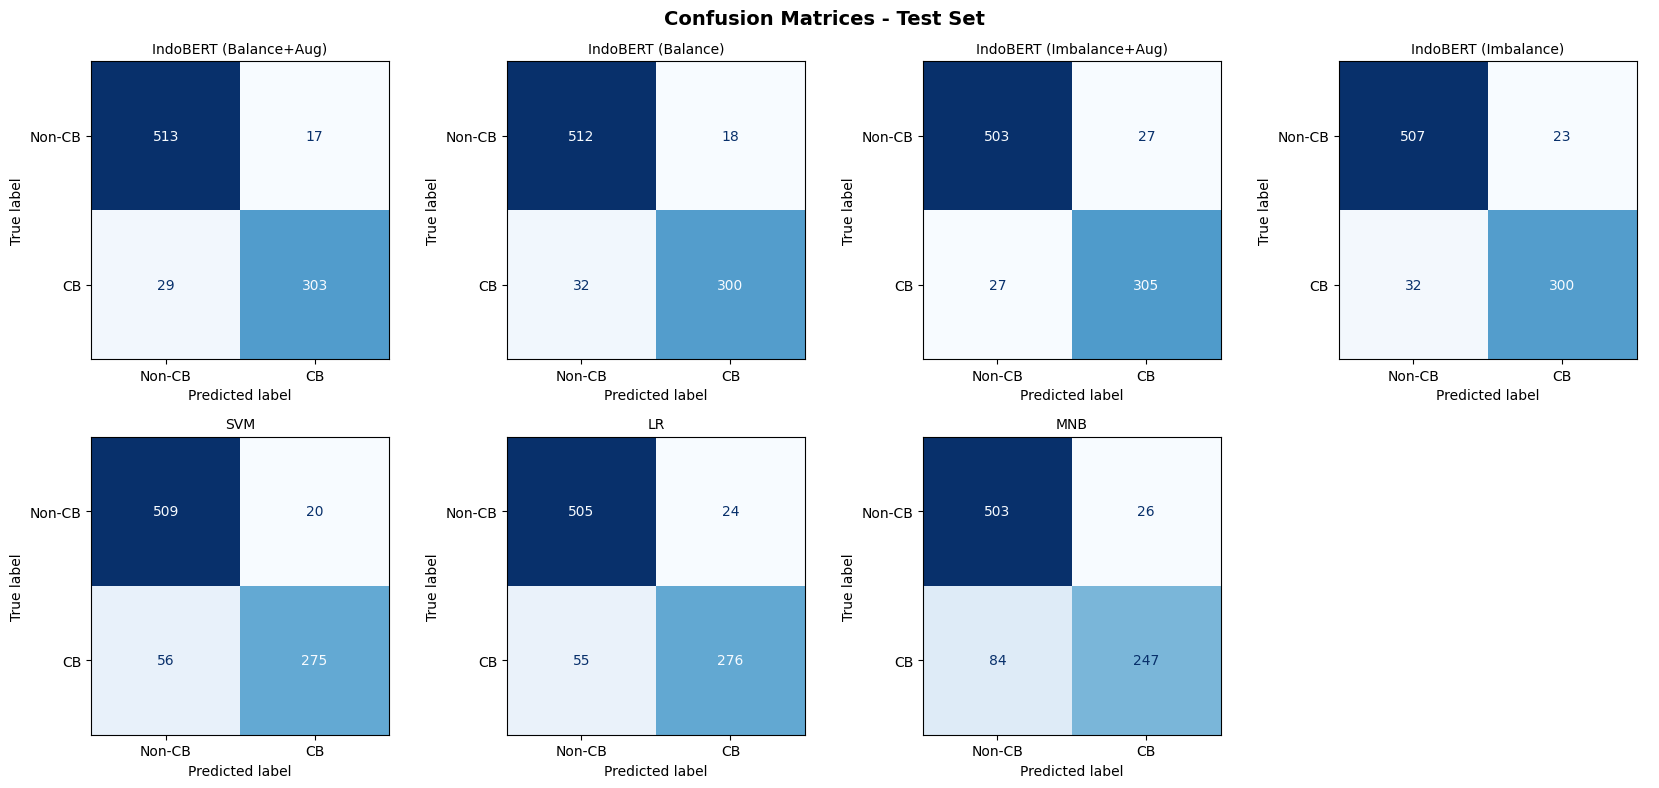

Saved: /content/drive/MyDrive/NLPAOL_V3/outputs_indobert/final_results/confusion_matrices.png


In [8]:
# ============================================================
# 7. Confusion Matrices: All Available Models
# ============================================================

cm_items = []
for r in rows:
    cm = validate_cm(r.get("cm"))
    if cm is not None:
        cm_items.append((short_model_name(r["Model"]), cm))

if not cm_items:
    print("No confusion matrices available.")
else:
    n = len(cm_items)
    cols = min(4, n)
    rows_plot = math.ceil(n / cols)

    fig, axes = plt.subplots(rows_plot, cols, figsize=(4.2 * cols, 4.0 * rows_plot))
    axes = np.array(axes).reshape(-1)

    fig.suptitle("Confusion Matrices - Test Set", fontsize=14, fontweight="bold")

    for ax, (name, cm) in zip(axes, cm_items):
        disp = ConfusionMatrixDisplay(
            confusion_matrix=np.array(cm),
            display_labels=["Non-CB", "CB"],
        )
        disp.plot(ax=ax, colorbar=False, cmap="Blues")
        ax.set_title(name, fontsize=10)

    # Hide unused axes
    for ax in axes[len(cm_items):]:
        ax.axis("off")

    plt.tight_layout()
    out_path = OUTPUT_DIR / "confusion_matrices.png"
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path}")

## 9. IndoBERT-only Confusion Matrices

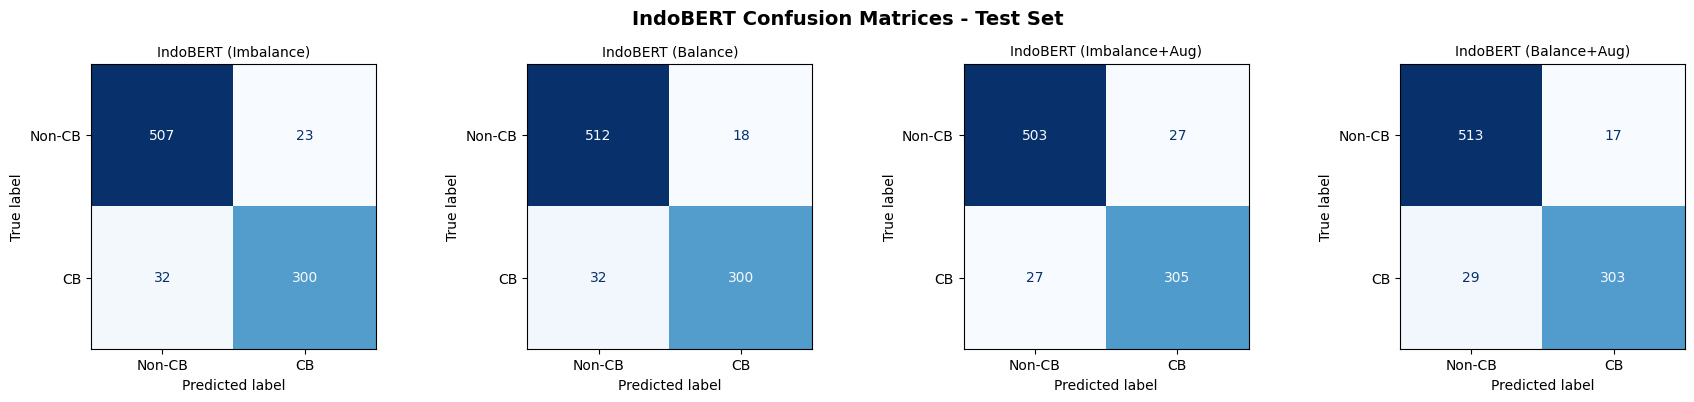

Saved: /content/drive/MyDrive/NLPAOL_V3/outputs_indobert/final_results/indobert_confusion_matrices_all.png


In [9]:
# ============================================================
# 8. IndoBERT-only Confusion Matrices
# ============================================================

indobert_order = [
    "indobert_imbalance",
    "indobert_balance",
    "indobert_imbalance_augment",
    "indobert_balance_augment",
]

bert_cm_items = []
for exp in indobert_order:
    r = indobert_results.get(exp)
    if not r:
        continue

    cm = validate_cm(r.get("confusion_matrix"))
    if cm is not None:
        bert_cm_items.append((f"IndoBERT ({SETTING_LABELS.get(exp, exp)})", cm))

if not bert_cm_items:
    print("No IndoBERT confusion matrices available.")
else:
    n = len(bert_cm_items)
    fig, axes = plt.subplots(1, n, figsize=(4.4 * n, 4))
    axes = np.array([axes]).reshape(-1)  # works for n=1 and n>1

    fig.suptitle("IndoBERT Confusion Matrices - Test Set", fontsize=14, fontweight="bold")

    for ax, (title, cm) in zip(axes, bert_cm_items):
        disp = ConfusionMatrixDisplay(
            confusion_matrix=np.array(cm),
            display_labels=["Non-CB", "CB"],
        )
        disp.plot(ax=ax, colorbar=False, cmap="Blues")
        ax.set_title(title, fontsize=10)

    plt.tight_layout()
    out_path = OUTPUT_DIR / "indobert_confusion_matrices_all.png"
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path}")

## 10. Training History

Loaded training history from: /content/drive/MyDrive/NLPAOL_V3/outputs_indobert/indobert_model/indobert_balance/checkpoint-3710/trainer_state.json
Eval log entries: 7


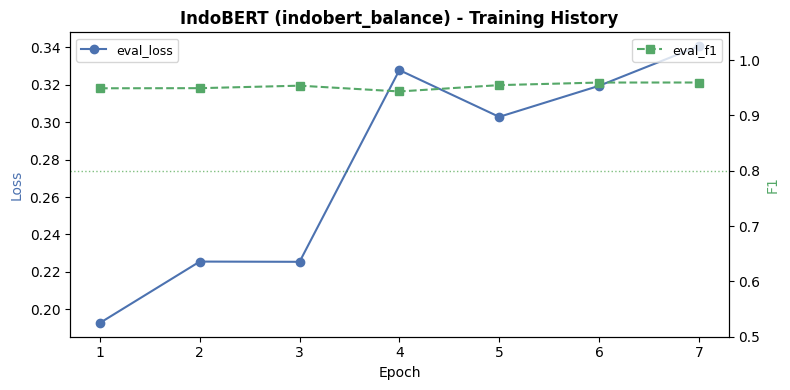

Saved: /content/drive/MyDrive/NLPAOL_V3/outputs_indobert/final_results/training_curve_indobert_balance.png


In [10]:
# ============================================================
# 9. IndoBERT Training History
# ============================================================

setting_dir = INDOBERT_MODEL_DIR / BEST_INDOBERT_EXPERIMENT

checkpoints = []
if setting_dir.exists():
    checkpoints = sorted(
        [d for d in setting_dir.glob("checkpoint-*") if d.is_dir()],
        key=lambda d: int(d.name.split("-")[-1]) if d.name.split("-")[-1].isdigit() else -1,
    )

history = None

if checkpoints:
    # Use the latest checkpoint's trainer_state.json for history
    state_file = checkpoints[-1] / "trainer_state.json"

    if state_file.exists():
        state = json.loads(state_file.read_text(encoding="utf-8"))
        history = [e for e in state.get("log_history", []) if "eval_loss" in e]
        print(f"Loaded training history from: {state_file}")
        print(f"Eval log entries: {len(history)}")
    else:
        print("trainer_state.json not found in latest checkpoint:", checkpoints[-1])
else:
    print("No checkpoint folder found for:", BEST_INDOBERT_EXPERIMENT)

if history:
    epochs_ = [e.get("epoch", i + 1) for i, e in enumerate(history)]
    eval_loss = [e.get("eval_loss") for e in history]

    f1_key = next(
        (k for k in ["eval_f1", "eval_f1_macro", "eval_f1_weighted"] if k in history[0]),
        None,
    )

    fig, ax1 = plt.subplots(figsize=(8, 4))
    ax1.set_title(
        f"IndoBERT ({BEST_INDOBERT_EXPERIMENT}) - Training History",
        fontsize=12,
        fontweight="bold",
    )
    ax1.plot(epochs_, eval_loss, "o-", color="#4C72B0", label="eval_loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss", color="#4C72B0")

    if f1_key:
        ax2 = ax1.twinx()
        ax2.plot(epochs_, [e.get(f1_key) for e in history], "s--", color="#55A868", label=f1_key)
        ax2.axhline(0.80, color="green", linestyle=":", alpha=0.5, linewidth=1)
        ax2.set_ylim(0.5, 1.05)
        ax2.set_ylabel("F1", color="#55A868")
        ax2.legend(loc="upper right", fontsize=9)

    ax1.legend(loc="upper left", fontsize=9)

    plt.tight_layout()
    out_path = OUTPUT_DIR / f"training_curve_{BEST_INDOBERT_EXPERIMENT}.png"
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path}")
else:
    print("Training curve not available. This is okay if checkpoint history was not saved.")

## 11. Final Summary

In [11]:
# ============================================================
# 10. Final Summary
# ============================================================

classical_rows = [r for r in rows if r["Type"] == "Classical"]
bert_rows = [r for r in rows if r["Type"] == "IndoBERT"]

best_classical = max(classical_rows, key=lambda x: x["F1"] if x["F1"] is not None else -1) if classical_rows else None
best_bert = max(bert_rows, key=lambda x: x["F1"] if x["F1"] is not None else -1) if bert_rows else None
best_overall = max(rows, key=lambda x: x["F1"] if x["F1"] is not None else -1) if rows else None

sep = "=" * 70
print(sep)
print("FINAL SUMMARY")
print(sep)

if best_classical:
    print()
    print(f"Best Classical : {best_classical['Model']}")
    print(f"  Accuracy     : {fmt(best_classical['Accuracy'])} [{target_check(best_classical['Accuracy'], 0.85)}]")
    print(f"  F1 macro     : {fmt(best_classical['F1'])} [{target_check(best_classical['F1'], 0.80)}]")
else:
    print("\nBest Classical : N/A")

if best_bert:
    print()
    print(f"Best IndoBERT  : {best_bert['Model']}")
    print(f"  Accuracy     : {fmt(best_bert['Accuracy'])} [{target_check(best_bert['Accuracy'], 0.85)}]")
    print(f"  F1 macro     : {fmt(best_bert['F1'])} [{target_check(best_bert['F1'], 0.80)}]")
else:
    print("\nBest IndoBERT  : N/A")

if best_overall:
    print()
    print(f"Best Overall   : {best_overall['Model']} (F1 = {fmt(best_overall['F1'])})")

print()
print("All models ranked by F1 macro:")
for i, r in enumerate(rows, 1):
    print(f"  {i}. {r['Model']:<42} F1={fmt(r['F1'])} Acc={fmt(r['Accuracy'])}")

print()
print("Targets: Accuracy >= 0.85, F1 >= 0.80")

FINAL SUMMARY

Best Classical : SVM (LinearSVC + Calibrated)
  Accuracy     : 0.9116 [PASS]
  F1 macro     : 0.9046 [PASS]

Best IndoBERT  : IndoBERT (Balance+Aug)
  Accuracy     : 0.9466 [PASS]
  F1 macro     : 0.9433 [PASS]

Best Overall   : IndoBERT (Balance+Aug) (F1 = 0.9433)

All models ranked by F1 macro:
  1. IndoBERT (Balance+Aug)                     F1=0.9433 Acc=0.9466
  2. IndoBERT (Balance)                         F1=0.9383 Acc=0.9420
  3. IndoBERT (Imbalance+Aug)                   F1=0.9339 Acc=0.9374
  4. IndoBERT (Imbalance)                       F1=0.9323 Acc=0.9362
  5. SVM (LinearSVC + Calibrated)               F1=0.9046 Acc=0.9116
  6. Logistic Regression                        F1=0.9011 Acc=0.9081
  7. Multinomial Naive Bayes                    F1=0.8597 Acc=0.8721

Targets: Accuracy >= 0.85, F1 >= 0.80


## 12. Save Results

In [12]:
# ============================================================
# 11. Save Combined Results
# ============================================================

combined = {
    "targets": {"accuracy": 0.85, "f1_macro": 0.80},
    "summary_table": rows,
    "classical_detail": classical,
    "indobert_results": indobert_results,
    "best_classical": best_classical["Model"] if best_classical else None,
    "best_indobert": best_bert["Model"] if best_bert else None,
    "best_overall": best_overall["Model"] if best_overall else None,
}

out_json = OUTPUT_DIR / "comparison_results.json"
with open(out_json, "w", encoding="utf-8") as f:
    json.dump(combined, f, indent=2, default=str)

summary_csv = OUTPUT_DIR / "comparison_summary_table.csv"
pd.DataFrame(rows).to_csv(summary_csv, index=False)

print(f"Saved JSON: {out_json}")
print(f"Saved CSV : {summary_csv}")

print()
print("Output files in final_results:")
for p in sorted(OUTPUT_DIR.iterdir()):
    print(" ", p.name)

Saved JSON: /content/drive/MyDrive/NLPAOL_V3/outputs_indobert/final_results/comparison_results.json
Saved CSV : /content/drive/MyDrive/NLPAOL_V3/outputs_indobert/final_results/comparison_summary_table.csv

Output files in final_results:
  comparison_bar_chart.png
  comparison_results.json
  comparison_summary_table.csv
  confusion_matrices.png
  indobert_all_experiments.csv
  indobert_balance_augment_report.txt
  indobert_balance_report.txt
  indobert_confusion_matrices_all.png
  indobert_confusion_matrices_from_checkpoints.csv
  indobert_confusion_matrices_from_checkpoints.json
  indobert_imbalance_augment_report.txt
  indobert_imbalance_report.txt
  tmp_eval
  training_curve_indobert_balance.png
